# SST and SSL Raw Histograms
This notebook visualizes the density maps (histograms) of the SST and SSL values across the weeks of the year without applying any curve fitting.

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from tqdm.auto import tqdm

plt.style.use('default')

In [3]:
# 1. Load the data
file_path = r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl'
try:
    with open(file_path, 'rb') as f:
        data = pickle.load(f)
    df = data['data']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

# Extract just SST and SSL
df_all_years = df.copy()
df_all_years['week'] = df_all_years.index.isocalendar().week

products = ['sst', 'ssl']
weekly_data = {p: [] for p in products}

for week_num, week_df in tqdm(df_all_years.groupby('week'), desc="Processing weeks"):
    for p in products:
        grids = []
        for _, row in week_df.iterrows():
            grid = row.get(p)
            if grid is not None and not (isinstance(grid, float) and np.isnan(grid)):
                grid_arr = np.array(grid, dtype=float)
                if not np.isnan(grid_arr).all():
                    grids.append(grid_arr)
        
        if grids:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', category=RuntimeWarning)
                avg_grid = np.nanmean(np.stack(grids), axis=0)
                values = avg_grid.flatten()
                values = values[~np.isnan(values)]
                
                if len(values) > 0:
                    for val in values:
                        weekly_data[p].append({'week': week_num, 'value': val})

for p in products:
    weekly_data[p] = pd.DataFrame(weekly_data[p])

Data loaded successfully.


Processing weeks:   0%|          | 0/53 [00:00<?, ?it/s]

In [4]:
# Function to create the density map (2D Histogram)
def get_density_map(df_p, y_bins_count=100):
    x_bins = np.arange(1, 54) - 0.5
    range_y = [df_p['value'].min(), df_p['value'].max()]
    
    h, xedges, yedges = np.histogram2d(
        df_p['week'], df_p['value'],
        bins=[x_bins, y_bins_count],
        range=[[0.5, 52.5], range_y]
    )
    
    x_centers = (xedges[:-1] + xedges[1:]) / 2
    y_centers = (yedges[:-1] + yedges[1:]) / 2
    
    return h, x_centers, y_centers

In [8]:
df_sst = weekly_data['sst']
h_sst, x_sst, y_sst = get_density_map(df_sst, y_bins_count=100)

## SST Density Map (Histogram)

In [9]:
# plt.figure(figsize=(10, 6))
# plt.imshow(h_sst.T, origin='lower', aspect='auto', 
#            extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
#            cmap='jet')
# plt.colorbar(label='Frequency')
# plt.title("SST Density Distribution")
# plt.xlabel("Week of Year")
# plt.ylabel("SST (°C)")
# plt.tight_layout()
# plt.show()

C:\Users\Makai\AppData\Local\Temp\ipykernel_48808\2177465059.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


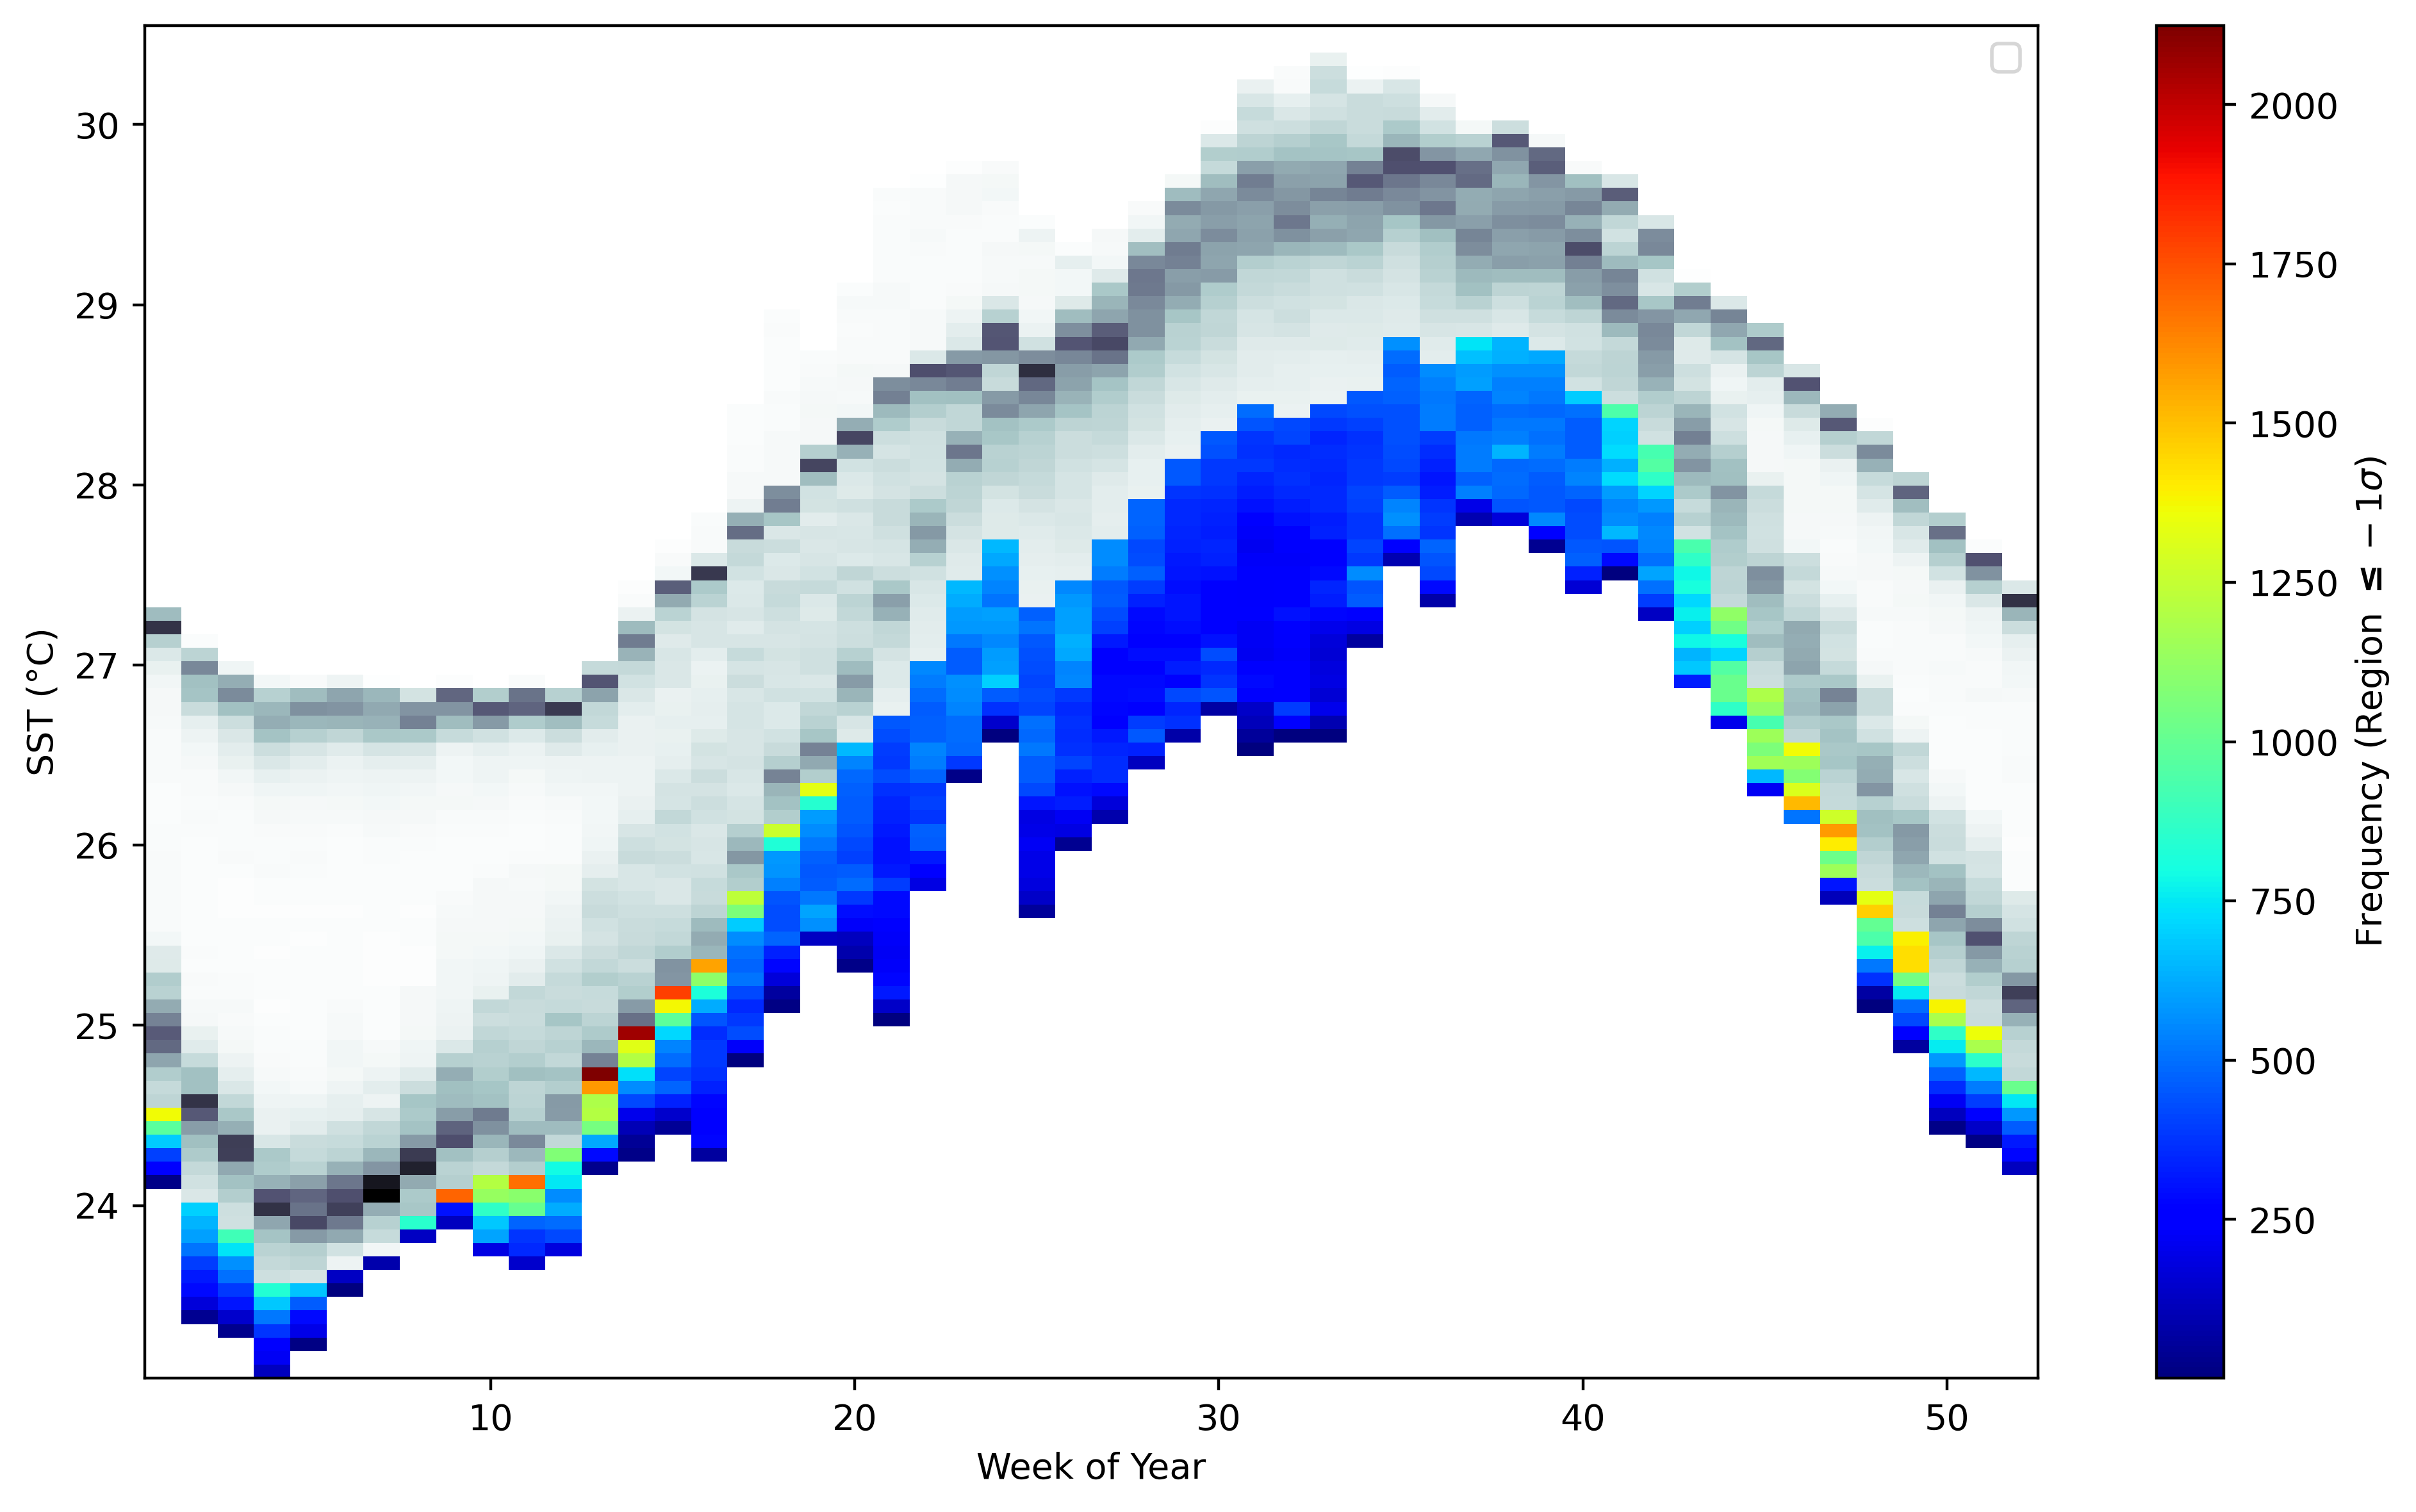

In [17]:
# Calculate weekly mean and stdev for SST
week_stats = df_sst.groupby('week')['value'].agg(['mean', 'std']).reset_index()
week_stats['threshold'] = week_stats['mean'] - week_stats['std']

plt.figure(figsize=(10, 6), dpi=400)

# Plot full density map in muted colors (e.g., bone or simply with low alpha)
plt.imshow(h_sst.T, origin='lower', aspect='auto', 
           extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
           cmap='bone_r', alpha=1)

# Create a highlighted histogram for values <= threshold
h_highlight = np.zeros_like(h_sst)
for i, week in enumerate(range(1, 53)):
    thresh = week_stats.loc[week_stats['week'] == week, 'threshold']
    if not thresh.empty:
        thresh_val = thresh.values[0]
        y_mask = y_sst <= thresh_val
        h_highlight[i, y_mask] = h_sst[i, y_mask]

# Mask zeros so they are transparent
h_highlight_masked = np.ma.masked_where(h_highlight == 0, h_highlight)

# Plot highlighted part in color
cax = plt.imshow(h_highlight_masked.T, origin='lower', aspect='auto', 
                 extent=[0.5, 52.5, y_sst.min(), y_sst.max()], 
                 cmap='jet')
plt.colorbar(cax, label=r'Frequency (Region $\mathbf{\leq} -1\sigma$)')

# Plot the threshold line
# plt.plot(week_stats['week'], week_stats['threshold'], color='red', lw=2, linestyle='-')
# plt.plot(week_stats['week'], week_stats['mean'], color='black', lw=2, linestyle='-', label='Mean')

# plt.title("SST Density Distribution (2018)")
plt.xlabel("Week of Year")
plt.ylabel("SST (°C)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the total % of SST data that is less than -1 stdev (threshold)
# Merge week_stats threshold into df_sst
sst_with_thresh = pd.merge(df_sst, week_stats[['week', 'threshold']], on='week', how='left')

# Boolean mask for values less than threshold
below_thresh = sst_with_thresh['value'] < sst_with_thresh['threshold']

# Calculate percentage
percent_below = below_thresh.sum() / len(sst_with_thresh) * 100
print(f"Total % of SST data less than -1 stdev: {percent_below:.2f}%")

Total % of SST data less than -1 stdev: 13.20%
